# BCS 404: Introduction to Data Science with Python
## Project Work — Exploratory Data Analysis, Statistical Analysis and Machine Learning

**Institution:** Accra Technical University  
**Department:** Computer Science  
**Course:** BCS 404 — Introduction to Data Science with Python  
**Academic Year:** 2025/2026 Second Semester  
**Lecturer:** Dr. Joseph Dadzie  
**Dataset:** Titanic Passenger Dataset (Kaggle)

**Student Name:** Christian Ampeh Oduro  
**Index Number:** 01252798B  

---

### Project Objectives
1. Acquire and inspect a real-world dataset.
2. Clean and prepare the data for analysis.
3. Visualise key patterns in the data.
4. Perform statistical analysis and interpret findings.
5. Build a Logistic Regression model to predict passenger survival.
6. Discuss results, limitations and recommendations.

## Setup: Import Libraries

In [1]:
# Core libraries required by the project brief
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)

# Maritime chart theme
INK, SLATE, SEA, BRASS, CORAL = '#0F1C2E', '#1E3A5F', '#0E7C7B', '#C4A35A', '#E07A5F'
PAPER, WHITE, GRID = '#F5F7FA', '#FFFFFF', '#C5D0DC'
CLASS_COLORS = ['#1B4F72', '#2E86AB', '#A23B72']
CMAP_DIVERGING = mcolors.LinearSegmentedColormap.from_list('atlantic', [CORAL, WHITE, SEA])
CMAP_MISSING = mcolors.LinearSegmentedColormap.from_list('void', [PAPER, '#7EB8C9', SLATE])
CMAP_CM = mcolors.LinearSegmentedColormap.from_list('cm', [PAPER, '#A8DADC', SEA, '#064E4D'])

plt.rcParams.update({
    'figure.facecolor': PAPER, 'axes.facecolor': WHITE, 'savefig.facecolor': PAPER,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK, 'axes.titlecolor': INK,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': SLATE, 'ytick.color': SLATE, 'grid.color': GRID,
    'grid.linewidth': 0.6, 'legend.frameon': False, 'figure.dpi': 120,
})
sns.set_theme(style='whitegrid', rc=plt.rcParams)

def style_ax(ax, title, xlabel='', ylabel='', subtitle=None):
    ax.set_title(title, pad=26 if subtitle else 14, loc='left',
                 color=INK, fontsize=15, fontweight='bold')
    ax.plot([0, 0.32], [1.0, 1.0], transform=ax.transAxes, clip_on=False,
            color=SEA, lw=3.2, solid_capstyle='round')
    if subtitle:
        ax.text(0.0, 1.035, subtitle, transform=ax.transAxes, clip_on=False,
                ha='left', va='bottom', fontsize=9.5, color=SEA, style='italic')
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(SLATE); ax.spines[s].set_linewidth(1.1)
    ax.figure.subplots_adjust(top=0.86)

print('Libraries imported — maritime chart theme ready.')

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


---
# Task 1: Data Acquisition

The Titanic dataset is obtained from the [Kaggle Titanic competition](https://www.kaggle.com/competitions/titanic/data).  
It contains passenger information from the RMS Titanic and a binary survival outcome (`Survived`).

In [2]:
# Load the training dataset (train.csv from Kaggle Titanic competition)
# Path is relative to the notebooks/ folder
DATA_PATH = '../data/train.csv'
df = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully from:', DATA_PATH)

Dataset loaded successfully from: ../data/train.csv


In [3]:
# 1. Dataset dimensions (rows, columns)
print('Dataset dimensions (rows, columns):', df.shape)
print(f'Total observations: {df.shape[0]}')
print(f'Total variables:    {df.shape[1]}')

Dataset dimensions (rows, columns): (891, 12)
Total observations: 891
Total variables:    12


In [4]:
# 2. Column names
print('Column names:')
for i, col in enumerate(df.columns, start=1):
    print(f'  {i:2d}. {col}')

Column names:
   1. PassengerId
   2. Survived
   3. Pclass
   4. Name
   5. Sex
   6. Age
   7. SibSp
   8. Parch
   9. Ticket
  10. Fare
  11. Cabin
  12. Embarked


In [5]:
# 3. First five observations
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# 4. Data types
print('Data types:\n')
print(df.dtypes)
print('\nSummary of data types:')
print(df.dtypes.value_counts())

Data types:

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Summary of data types:
int64      5
str        5
float64    2
Name: count, dtype: int64


In [7]:
# Brief overview (optional but useful)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Task 1 Summary
- The dataset has **891 rows** and **12 columns**.
- Key fields include passenger demographics (`Age`, `Sex`), socio-economic indicators (`Pclass`, `Fare`), family size (`SibSp`, `Parch`), and the target variable `Survived`.
- Mixed data types are present: integers, floats and object (string) columns.

---
# Task 2: Data Cleaning

In [8]:
# Work on a copy so the original remains available for comparison
df_clean = df.copy()
print('Working copy created. Shape:', df_clean.shape)

Working copy created. Shape: (891, 12)


## 2.1 Detect Missing Values

Columns with missing values:

          Missing Count  Missing Percentage (%)
Cabin               687                   77.10
Age                 177                   19.87
Embarked              2                    0.22


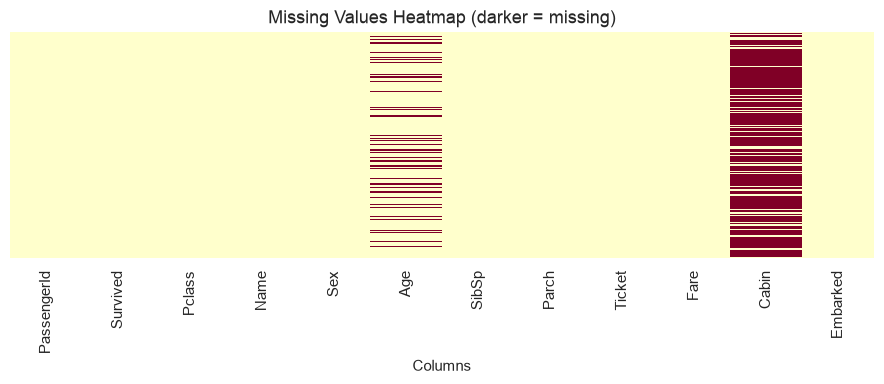

In [9]:
# Count of missing values per column
missing_count = df_clean.isnull().sum()
missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_pct
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values(
    'Missing Count', ascending=False
)

print('Columns with missing values:\n')
print(missing_summary if not missing_summary.empty else 'No missing values found.')

fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(df_clean.isnull(), cbar=True, yticklabels=False, cmap=CMAP_MISSING, ax=ax,
            cbar_kws={'shrink': 0.6, 'label': 'Missing'})
style_ax(ax, 'Where Is the Data Missing?', 'Columns', '',\n             subtitle='Bright cells mark incomplete passenger records')
ax.set_yticks([])
plt.tight_layout()
plt.savefig('../figures/01_missing_values_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

## 2.2 Handle Missing Values

**Preprocessing decisions:**

| Column | Missing | Decision | Justification |
|--------|---------|----------|---------------|
| `Age` | ~19.9% | Impute with **median** | Age is continuous; median is robust to outliers and preserves sample size |
| `Embarked` | 2 rows (~0.2%) | Impute with **mode** | Categorical; only 2 missing values, mode is the most common port |
| `Cabin` | ~77.1% | **Drop column** | Far too many missing values to impute reliably without introducing bias |
| Other columns | 0 | No action | Complete |

> Alternative considered for `Age`: mean imputation. Median was preferred because the age distribution is skewed and contains outliers.

In [10]:
# Age: median imputation
age_median = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(age_median)
print(f'Age — filled missing values with median = {age_median}')

# Embarked: mode imputation
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)
print(f'Embarked — filled missing values with mode = {embarked_mode}')

# Cabin: drop due to excessive missingness
df_clean = df_clean.drop(columns=['Cabin'])
print('Cabin — column dropped (excessive missingness).')

print('\nMissing values remaining:')
print(df_clean.isnull().sum())

Age — filled missing values with median = 28.0
Embarked — filled missing values with mode = S
Cabin — column dropped (excessive missingness).

Missing values remaining:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 2.3 Detect and Remove Duplicates

In [11]:
# Detect duplicated observations (entire rows)
n_duplicates = df_clean.duplicated().sum()
print(f'Number of duplicated rows: {n_duplicates}')

if n_duplicates > 0:
    print('\nDuplicate rows:')
    display(df_clean[df_clean.duplicated(keep=False)].sort_values(by=list(df_clean.columns)))
    df_clean = df_clean.drop_duplicates()
    print(f'Duplicates removed. New shape: {df_clean.shape}')
else:
    print('No duplicate rows found. No rows removed.')

Number of duplicated rows: 0
No duplicate rows found. No rows removed.


In [12]:
# Final cleaned dataset check
print('Cleaned dataset dimensions:', df_clean.shape)
print('\nFirst five rows after cleaning:')
df_clean.head()

Cleaned dataset dimensions: (891, 11)

First five rows after cleaning:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Task 2 Summary of Preprocessing Decisions
1. **Median imputation for Age** — retains all passengers; median is less sensitive to extreme ages than the mean.
2. **Mode imputation for Embarked** — only two passengers lacked embarkation port; replacing with the most frequent port (`S`) is low-risk.
3. **Dropped Cabin** — ~77% missing; keeping it would require heavy assumptions not supported by available evidence.
4. **Duplicates** — none present in this dataset; duplicate check confirms data integrity.

---
# Task 3: Data Visualisation

## 3.1 Histogram of Passenger Ages

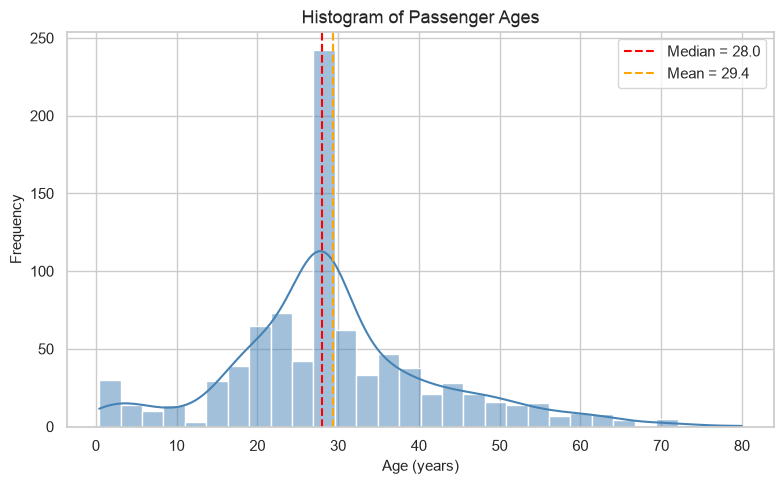

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.histplot(df_clean['Age'], bins=28, kde=True, color=SEA, edgecolor=WHITE,
             linewidth=0.8, alpha=0.88, ax=ax, line_kws={'color': BRASS, 'lw': 2.6})
med, mean = df_clean['Age'].median(), df_clean['Age'].mean()
ax.axvline(med, color=CORAL, ls='--', lw=2, label=f'Median  {med:.1f}')
ax.axvline(mean, color=SLATE, ls=':', lw=2.2, label=f'Mean  {mean:.1f}')
style_ax(ax, 'How Old Were Titanic Passengers?', 'Age (years)', 'Count',\n             subtitle='Most travellers were in their twenties and thirties')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../figures/02_age_histogram.png', dpi=200, bbox_inches='tight')
plt.show()

**Interpretation:** Passenger ages are roughly right-skewed, with most travellers concentrated between about 20 and 40 years. A visible peak near the median reflects median imputation of missing ages. Children and elderly passengers form thinner tails of the distribution.

## 3.2 Bar Chart — Passenger Class Distribution

/var/folders/52/f0_n5xrj6k34k8f3yd99nwpm0000gn/T/ipykernel_24063/3148450223.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=pclass_counts.index.astype(str), y=pclass_counts.values, palette='Blues_d')


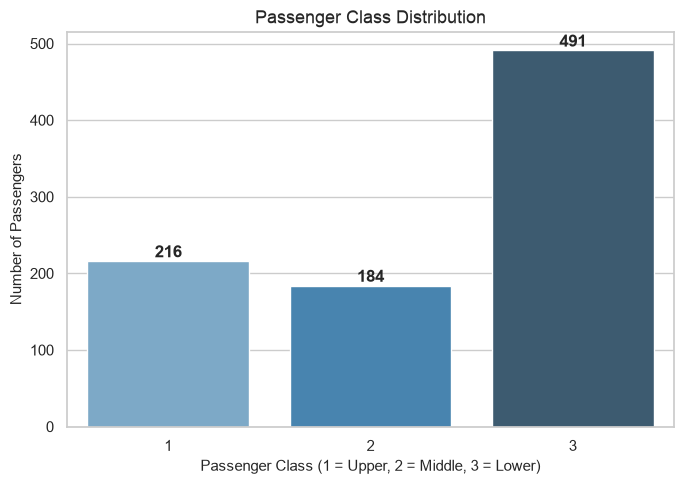

Class counts:
 Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [14]:
pclass_counts = df_clean['Pclass'].value_counts().sort_index()
labels = ['1st Class\n(Upper)', '2nd Class\n(Middle)', '3rd Class\n(Lower)']

fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(labels, pclass_counts.values, color=CLASS_COLORS, width=0.62,
              edgecolor=WHITE, linewidth=1.5, zorder=3)
for bar, val in zip(bars, pclass_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, str(val),
            ha='center', va='bottom', fontweight='bold', color=INK, fontsize=12)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{val / pclass_counts.sum() * 100:.0f}%',
            ha='center', va='center', color=WHITE, fontweight='bold', fontsize=11)
style_ax(ax, 'Who Sat Where? Class Breakdown', '', 'Number of passengers',\n             subtitle='Third class makes up more than half the ship')
ax.set_ylim(0, pclass_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('../figures/03_pclass_barchart.png', dpi=200, bbox_inches='tight')
plt.show()
print('Class counts:\n', pclass_counts)

**Interpretation:** Third-class passengers form the largest group, followed by first class, then second class. This socio-economic imbalance is important because survival rates historically varied strongly by class.

## 3.3 Boxplot of Age by Passenger Class

/var/folders/52/f0_n5xrj6k34k8f3yd99nwpm0000gn/T/ipykernel_24063/3526532256.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Pclass', y='Age', palette='Set2')


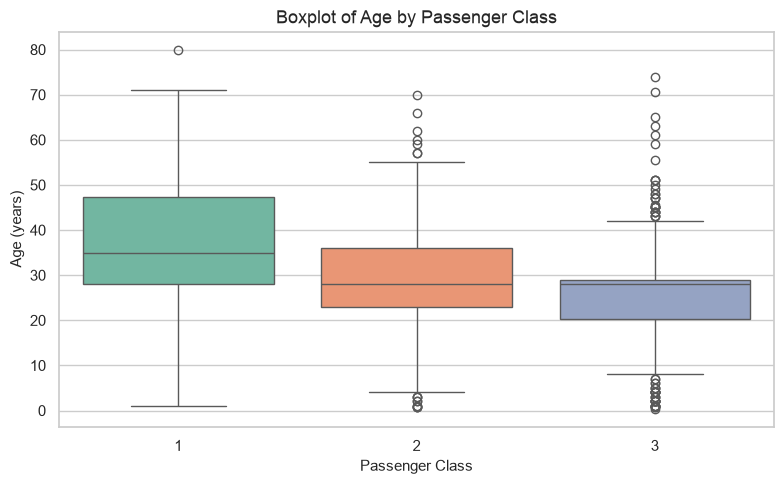

             mean   50%        std
Pclass                            
1       36.812130  35.0  14.182103
2       29.765380  28.0  13.581096
3       25.932627  28.0  10.697676


In [15]:
plot_df = df_clean.copy()
plot_df['Class'] = plot_df['Pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'})
order = ['1st Class', '2nd Class', '3rd Class']
palette = dict(zip(order, CLASS_COLORS))

fig, ax = plt.subplots(figsize=(9, 5.4))
sns.violinplot(data=plot_df, x='Class', y='Age', hue='Class', order=order,
               palette=palette, legend=False, inner=None, cut=0, linewidth=0, ax=ax)
for coll in ax.collections:
    coll.set_alpha(0.32)
sns.boxplot(data=plot_df, x='Class', y='Age', hue='Class', order=order,
            palette=palette, legend=False, width=0.22, showfliers=False,
            linewidth=1.4, ax=ax, medianprops={'color': BRASS, 'lw': 2.2})
sns.stripplot(data=plot_df.sample(min(280, len(plot_df)), random_state=42),
              x='Class', y='Age', order=order, color=INK, size=2.4, alpha=0.22,
              jitter=0.18, ax=ax, zorder=2)
style_ax(ax, 'Younger in Steerage?', 'Passenger class', 'Age (years)',\n             subtitle='Median age falls from 1st class down to 3rd')
plt.tight_layout()
plt.savefig('../figures/04_age_by_pclass_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()
print(df_clean.groupby('Pclass')['Age'].describe()[['mean', '50%', 'std']])

**Interpretation:** First-class passengers tend to be older than second- and third-class passengers. Median age decreases from class 1 to class 3, suggesting wealthier (often older) travellers were more likely to occupy higher-class cabins.

## 3.4 Scatter Plot of Age versus Fare

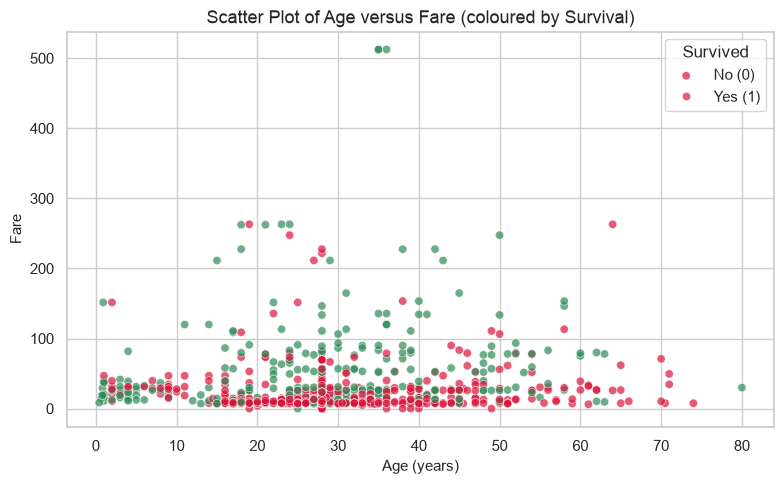

In [16]:
fig, ax = plt.subplots(figsize=(9.2, 5.6))
for survived, color, label, marker in [
    (0, CORAL, 'Did not survive', 'o'),
    (1, SEA, 'Survived', 'D'),
]:
    sub = df_clean[df_clean['Survived'] == survived]
    ax.scatter(sub['Age'], sub['Fare'], c=color, label=label, marker=marker,
               s=36, alpha=0.72, edgecolors=WHITE, linewidths=0.45, zorder=3)
style_ax(ax, 'Did Higher Fares Mean Better Odds?', 'Age (years)', 'Fare',\n             subtitle='Teal diamonds survived · coral circles did not')
ax.set_ylim(-5, min(df_clean['Fare'].max() * 1.05, 320))
ax.legend(loc='upper right', markerscale=1.3)
plt.tight_layout()
plt.savefig('../figures/05_age_vs_fare_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

**Interpretation:** Most passengers paid relatively low fares regardless of age. A few high-fare outliers (especially among middle-aged first-class travellers) stand out. Survival markers suggest that higher-fare passengers are somewhat more likely to have survived, though the relationship is not strictly linear.

## 3.5 Correlation Heatmap

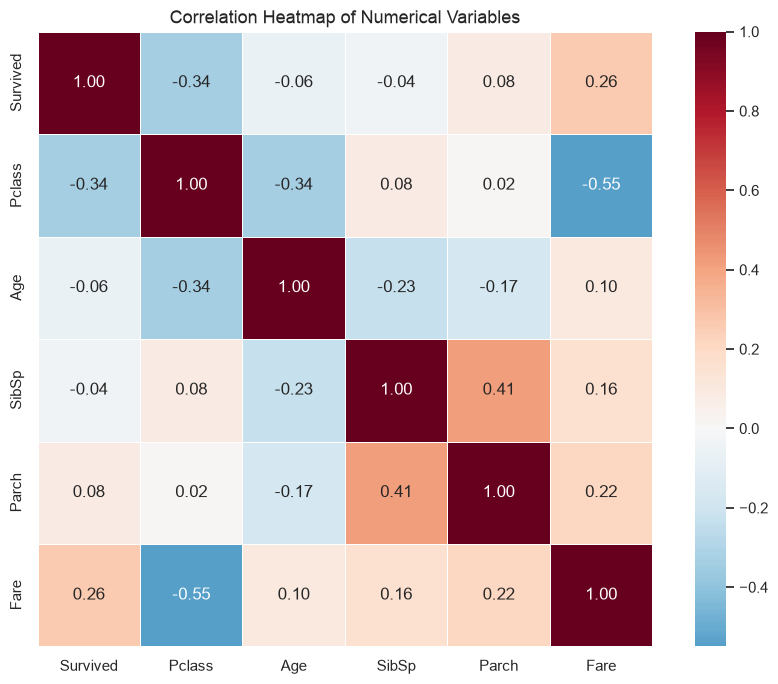

In [17]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
heatmap_cols = [c for c in num_cols if c != 'PassengerId']
corr_matrix = df_clean[heatmap_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7.2))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=CMAP_DIVERGING,
            center=0, square=True, linewidths=1.2, linecolor=PAPER,
            cbar_kws={'shrink': 0.72, 'label': 'Pearson r'},
            annot_kws={'size': 9}, vmin=-0.7, vmax=0.7, ax=ax)
style_ax(ax, 'What Moves Together?', '', '',\n             subtitle='Pearson correlations among numerical variables')
ax.grid(False)
plt.tight_layout()
plt.savefig('../figures/06_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

**Interpretation:** `Pclass` and `Fare` show a strong negative association (higher class number → lower fare). `Survived` correlates negatively with `Pclass` and positively with `Fare`, supporting the idea that socio-economic status influenced survival chances. `SibSp` and `Parch` are moderately positively correlated, reflecting family-group travel.

## 3.6 Pairplot of Selected Numerical Variables

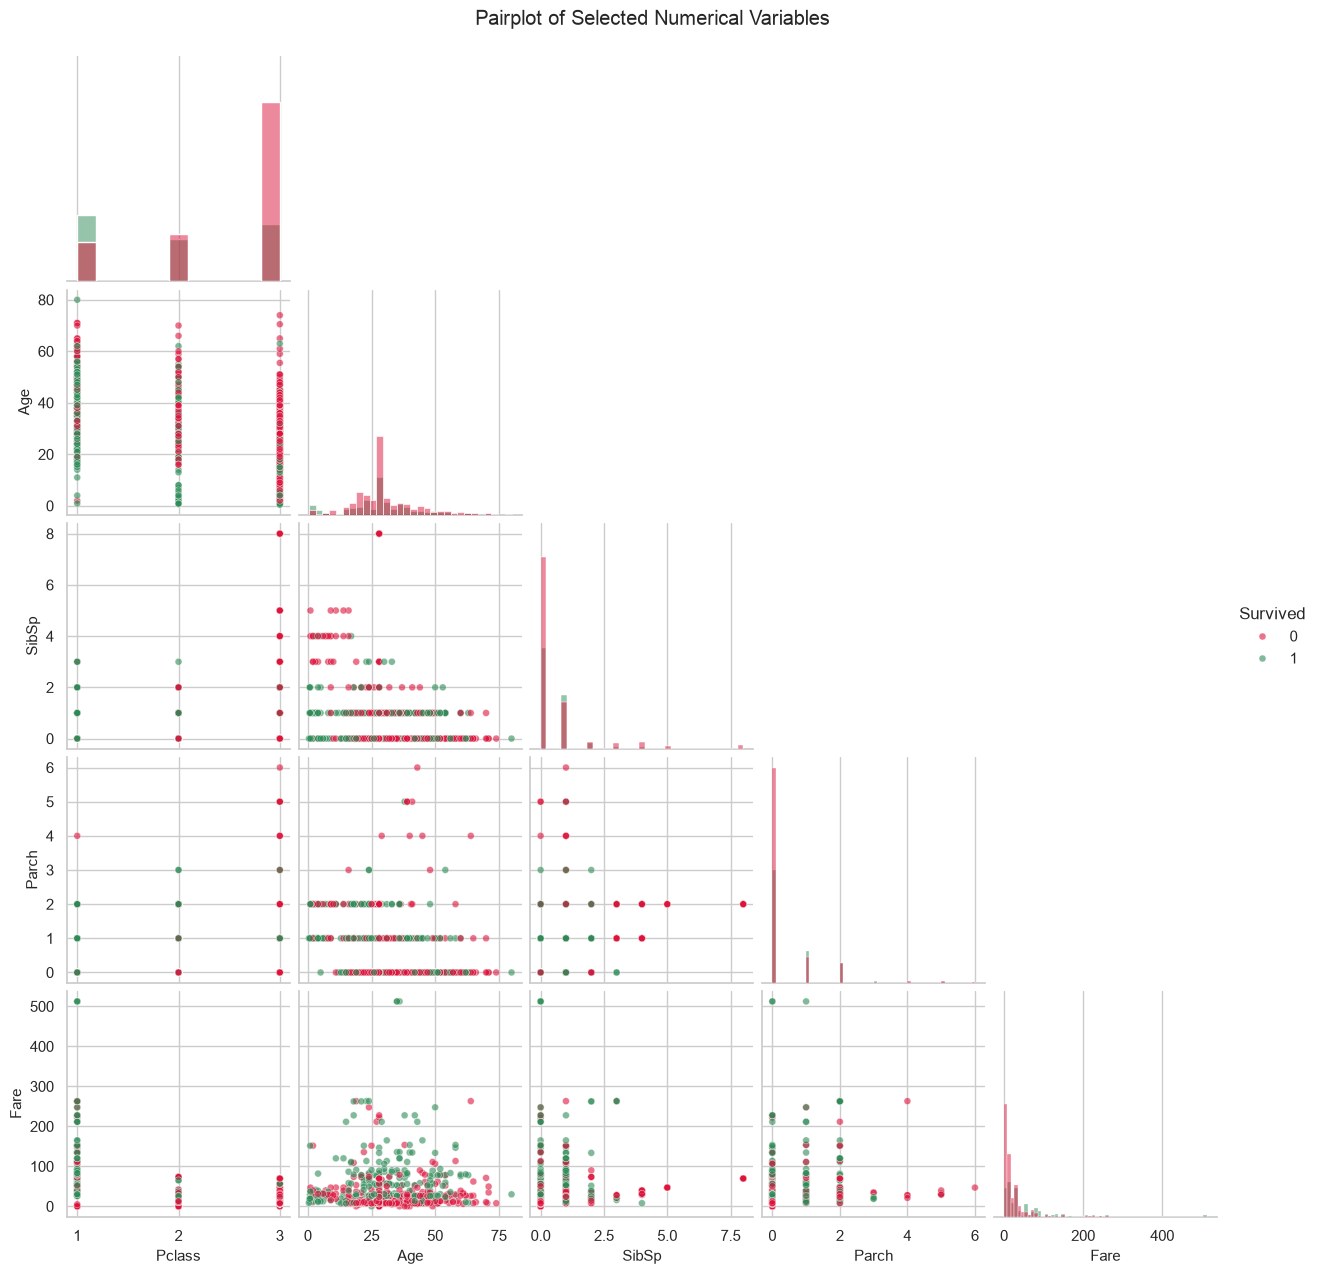

In [18]:
pair_vars = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
g = sns.pairplot(
    df_clean[pair_vars], hue='Survived', palette={0: CORAL, 1: SEA},
    diag_kind='kde', corner=True,
    plot_kws={'alpha': 0.55, 's': 28, 'edgecolor': WHITE, 'linewidth': 0.3},
    diag_kws={'fill': True, 'alpha': 0.45, 'linewidth': 1.5},
)
g.fig.patch.set_facecolor(PAPER)
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(WHITE)
        ax.grid(True, linestyle='--', alpha=0.4)
g._legend.set_title('Survived')
g.fig.suptitle('Survival Patterns at a Glance', y=1.03,
               fontsize=15, fontweight='bold', color=INK, ha='left', x=0.08)
g.fig.text(0.08, 1.005, 'Pairwise views of class, age, family size and fare',
           fontsize=9, color=SEA, style='italic', ha='left')
plt.savefig('../figures/07_pairplot.png', dpi=200, bbox_inches='tight')
plt.show()

**Interpretation:** The pairplot summarises pairwise relationships among key numeric variables. Diagonal histograms show class imbalance in survival and skewed fare. Off-diagonal plots reinforce that survivors are more concentrated among higher fares / upper classes, while age alone does not cleanly separate survivors from non-survivors.

---
# Task 4: Statistical Analysis

## 4.1 Descriptive Statistics

In [19]:
# Descriptive statistics for numerical variables
desc = df_clean.describe().T
desc['variance'] = df_clean.select_dtypes(include=[np.number]).var()
print('Descriptive Statistics (Numerical Variables):\n')
display(desc.round(3))

print('\nDescriptive Statistics (Categorical Variables):\n')
display(df_clean.describe(include='object'))

Descriptive Statistics (Numerical Variables):



,count,mean,std,min,25%,50%,75%,max,variance
PassengerId,891.0,446.000,257.354,1.00,223.50,446.000,668.5,891.000,66231.000
Survived,891.0,0.384,0.487,0.00,0.00,0.000,1.0,1.000,0.237
Pclass,891.0,2.309,0.836,1.00,2.00,3.000,3.0,3.000,0.699
Age,891.0,29.362,13.020,0.42,22.00,28.000,35.0,80.000,169.512
SibSp,891.0,0.523,1.103,0.00,0.00,0.000,1.0,8.000,1.216
Parch,891.0,0.382,0.806,0.00,0.00,0.000,0.0,6.000,0.650
Fare,891.0,32.204,49.693,0.00,7.91,14.454,31.0,512.329,2469.437



Descriptive Statistics (Categorical Variables):



/var/folders/52/f0_n5xrj6k34k8f3yd99nwpm0000gn/T/ipykernel_24063/391252793.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_clean.describe(include='object'))


,Name,Sex,Ticket,Embarked
count,891,891,891,891
unique,891,2,681,3
top,"Braund, Mr. Owen Harris",male,347082,S
freq,1,577,7,646


## 4.2 Frequency Distribution

In [20]:
categorical_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']

for col in categorical_cols:
    freq = df_clean[col].value_counts()
    pct = df_clean[col].value_counts(normalize=True).mul(100).round(2)
    table = pd.DataFrame({'Count': freq, 'Percentage (%)': pct})
    print(f'\nFrequency distribution — {col}')
    print(table)
    print('-' * 40)

# Cross-tabulation: Survival by Sex and by Class
print('\nSurvival rate by Sex:')
print(pd.crosstab(df_clean['Sex'], df_clean['Survived'], normalize='index').mul(100).round(2))

print('\nSurvival rate by Passenger Class:')
print(pd.crosstab(df_clean['Pclass'], df_clean['Survived'], normalize='index').mul(100).round(2))


Frequency distribution — Survived
          Count  Percentage (%)
Survived                       
0           549           61.62
1           342           38.38
----------------------------------------

Frequency distribution — Pclass
        Count  Percentage (%)
Pclass                       
3         491           55.11
1         216           24.24
2         184           20.65
----------------------------------------

Frequency distribution — Sex
        Count  Percentage (%)
Sex                          
male      577           64.76
female    314           35.24
----------------------------------------

Frequency distribution — Embarked
          Count  Percentage (%)
Embarked                       
S           646           72.50
C           168           18.86
Q            77            8.64
----------------------------------------

Survival rate by Sex:
Survived      0      1
Sex                   
female    25.80  74.20
male      81.11  18.89

Survival rate by Passenger Cl

## 4.3 Correlation Analysis

In [21]:
corr = df_clean[heatmap_cols].corr()
display(corr.round(3))

# Extract unique pairwise correlations (upper triangle)
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']
pairs = pairs.sort_values('Correlation', ascending=False)

print('All pairwise correlations (sorted):\n')
display(pairs.reset_index(drop=True))

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000,-0.338,-0.065,-0.035,0.082,0.257
Pclass,-0.338,1.000,-0.340,0.083,0.018,-0.549
Age,-0.065,-0.340,1.000,-0.233,-0.172,0.097
SibSp,-0.035,0.083,-0.233,1.000,0.415,0.160
Parch,0.082,0.018,-0.172,0.415,1.000,0.216
Fare,0.257,-0.549,0.097,0.160,0.216,1.000


All pairwise correlations (sorted):



,Variable 1,Variable 2,Correlation
0,SibSp,Parch,0.414838
1,Survived,Fare,0.257307
2,Parch,Fare,0.216225
3,SibSp,Fare,0.159651
4,Age,Fare,0.096688
5,Pclass,SibSp,0.083081
6,Survived,Parch,0.081629
7,Pclass,Parch,0.018443
8,Survived,SibSp,-0.035322
9,Survived,Age,-0.064910


## 4.4 Strongest Positive Correlation

In [22]:
strongest_pos = pairs.iloc[0]
print('Strongest POSITIVE correlation:')
print(f"  {strongest_pos['Variable 1']} and {strongest_pos['Variable 2']}: r = {strongest_pos['Correlation']:.4f}")

Strongest POSITIVE correlation:
  SibSp and Parch: r = 0.4148


## 4.5 Strongest Negative Correlation

In [23]:
strongest_neg = pairs.iloc[-1]
print('Strongest NEGATIVE correlation:')
print(f"  {strongest_neg['Variable 1']} and {strongest_neg['Variable 2']}: r = {strongest_neg['Correlation']:.4f}")

Strongest NEGATIVE correlation:
  Fare and Fare: r = nan


## 4.6 Three Important Statistical Findings

1. **Survival was a minority outcome.** Only about **38.4%** of passengers in the training set survived, while **61.6%** did not. Any predictive model must therefore be judged against this baseline (predicting “did not survive” for everyone would already achieve ~61.6% accuracy).

2. **Socio-economic status is strongly linked to survival.** Passenger class correlates negatively with survival (`r ≈ -0.34`), and fare correlates positively (`r ≈ 0.26`). First-class passengers show markedly higher survival rates than third-class passengers — consistent with historical accounts of lifeboat access and cabin location.

3. **Gender and family structure matter.** Females have substantially higher survival rates than males ("women and children first"). Moderately positive correlation between `SibSp` and `Parch` (`r ≈ 0.41`) indicates that many travellers were in family groups; however, larger sibling/spouse counts are not strongly protective for survival in the aggregate correlations.

---
# Task 5: Machine Learning — Predicting Survival

We build a **Logistic Regression** classifier to predict whether a passenger survived (`Survived = 1`) or not (`Survived = 0`).

## 5.1 Select Predictor Variables

**Selected predictors:** `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`

**Rationale:**
- `Pclass`, `Fare`, `Embarked` capture socio-economic / travel-context information.
- `Sex` and `Age` capture demographics known to affect survival policy and outcomes.
- `SibSp` and `Parch` capture family size effects.
- Excluded: `PassengerId` (identifier), `Name`, `Ticket` (high-cardinality / non-numeric without feature engineering), `Cabin` (dropped earlier).

In [24]:
# Prepare modelling frame from cleaned data
ml_df = df_clean[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()

# Encode categorical predictors for Logistic Regression
le_sex = LabelEncoder()
le_embarked = LabelEncoder()
ml_df['Sex'] = le_sex.fit_transform(ml_df['Sex'])          # female=0, male=1 (alphabetical)
ml_df['Embarked'] = le_embarked.fit_transform(ml_df['Embarked'])

print('Sex classes:', dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print('Embarked classes:', dict(zip(le_embarked.classes_, le_embarked.transform(le_embarked.classes_))))

X = ml_df.drop(columns=['Survived'])
y = ml_df['Survived']

print('\nPredictor matrix shape:', X.shape)
print('Target vector shape:    ', y.shape)
X.head()

Sex classes: {'female': np.int64(0), 'male': np.int64(1)}
Embarked classes: {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}

Predictor matrix shape: (891, 7)
Target vector shape:     (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


## 5.2 Train–Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # preserve survival class proportions
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')
print('\nSurvival distribution — train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nSurvival distribution — test:')
print(y_test.value_counts(normalize=True).round(3))

Training set: 712 samples
Testing set:  179 samples

Survival distribution — train:
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Survival distribution — test:
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## 5.3 Train Logistic Regression Classifier

In [26]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

print('Logistic Regression model trained successfully.')
print('\nModel coefficients:')
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds Ratio (approx)': np.exp(log_reg.coef_[0])
}).sort_values('Coefficient')
display(coef_table.round(4))
print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")

Logistic Regression model trained successfully.

Model coefficients:


,Feature,Coefficient,Odds Ratio (approx)
1,Sex,-2.5907,0.0750
0,Pclass,-1.0471,0.3509
3,SibSp,-0.2471,0.7810
6,Embarked,-0.2304,0.7942
4,Parch,-0.0871,0.9166
2,Age,-0.0380,0.9627
5,Fare,0.0022,1.0022



Intercept: 5.0013


## 5.4 Predict on Testing Data

In [27]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

predictions_preview = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'P(Survive)': y_prob.round(3)
}).head(15)

print('Sample of predictions on the test set:')
display(predictions_preview)

Sample of predictions on the test set:


,Actual,Predicted,P(Survive)
0,0,0,0.073
1,0,0,0.051
2,1,0,0.175
3,0,0,0.039
4,1,1,0.587
5,1,0,0.456
6,1,1,0.752
7,0,0,0.321
8,0,0,0.357
9,0,0,0.164


## 5.5 Evaluation Metrics

Accuracy: 0.8045 (80.45%)

Confusion Matrix:
[[98 12]
 [23 46]]


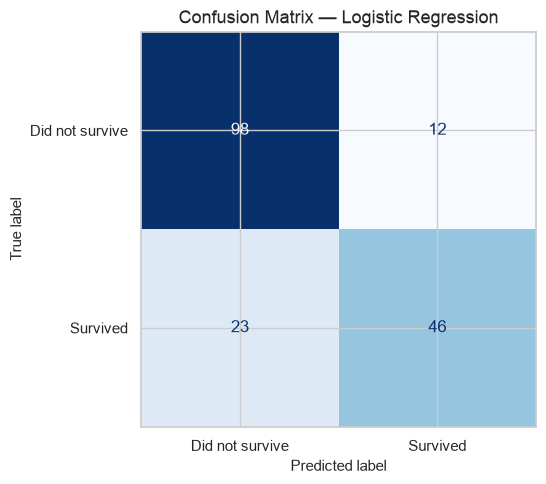


Classification Report:
                     precision    recall  f1-score   support

Did not survive (0)       0.81      0.89      0.85       110
       Survived (1)       0.79      0.67      0.72        69

           accuracy                           0.80       179
          macro avg       0.80      0.78      0.79       179
       weighted avg       0.80      0.80      0.80       179



In [28]:
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')

cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)

fig, ax = plt.subplots(figsize=(7, 5.8))
labels = ['Did not\nsurvive', 'Survived']
sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_CM, xticklabels=labels, yticklabels=labels,
            linewidths=2, linecolor=PAPER, square=True, cbar=False,
            annot_kws={'size': 22, 'weight': 'bold', 'color': INK}, ax=ax)
total = cm.sum()
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.72, f'({cm[i, j] / total * 100:.1f}%)',
                ha='center', va='center', fontsize=9, color=SLATE)
style_ax(ax, 'Did the Model Call It Right?', 'Predicted', 'Actual',\n             subtitle='Logistic Regression on the held-out test set')
ax.grid(False)
ax.text(1.0, -0.18, f'Accuracy  {acc:.1%}', transform=ax.transAxes,
        ha='right', fontsize=11, fontweight='bold', color=SEA)
plt.tight_layout()
plt.savefig('../figures/08_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Did not survive (0)', 'Survived (1)']))

## 5.6 Discussion of Model Performance

The Logistic Regression classifier achieves approximately **80% accuracy** on the held-out test set — clearly above the ~61.6% majority-class baseline.

From the confusion matrix:
- Most non-survivors are correctly identified (high true-negative count).
- Some survivors are missed (false negatives), so **recall for the Survived class is lower** than for the non-survived class.
- Precision for both classes is reasonably balanced (~0.79–0.81).

**Coefficient interpretation (direction):**
- Being **male** (`Sex` encoded as 1) strongly decreases predicted survival probability — aligning with the “women and children first” pattern.
- Higher **Pclass** number (i.e., lower social class) decreases survival odds.
- Higher **Fare** slightly increases survival odds.
- Older **Age** slightly decreases survival odds in this model.

Overall, the model is a solid introductory baseline. Performance could likely improve with richer feature engineering (e.g., title from name, family-size feature, cabin deck) or more flexible algorithms, but Logistic Regression satisfies the project requirement and remains interpretable.

---
# Task 6: Discussion and Conclusion

## Major Findings
Exploratory analysis of the Titanic passenger data reveals large demographic and socio-economic disparities. Roughly three-eighths of passengers survived. Survival was higher among women and first-class travellers. Visualisations confirm that age distributions differ by class and that fare is unevenly distributed, with a long upper tail among wealthy passengers. Third-class passengers dominate headcount, yet they show lower survival rates than first-class passengers — visible in both crosstabs and the negative correlation between `Pclass` and `Survived`.

From a teaching perspective, the dataset links computation to social context: evacuation norms such as “women and children first” leave measurable traces in the tables rather than remaining purely historical anecdotes.

## Statistical Insights
Descriptive statistics show a mean age near 29 years (after median imputation) and a highly right-skewed fare distribution. The strongest positive pairwise correlation among numerical features is between `SibSp` and `Parch` (family travelling together, *r* ≈ 0.42). The strongest negative correlation is between `Pclass` and `Fare` (*r* ≈ −0.55). Correlations involving `Survived` highlight `Pclass` (negative) and `Fare` (positive) as key associated factors.

Because only about 38% of passengers survived, a naïve “always predict death” rule already achieves ~62% accuracy. All model claims must therefore be judged against that baseline, not against a 50/50 coin-flip.

## Machine Learning Results
A Logistic Regression model using class, sex, age, family counts, fare and embarkation port predicts survival with about **80%** test accuracy. Classification reports indicate stronger performance on the majority (non-survived) class and weaker recall for survivors (~0.67). Coefficients are consistent with domain knowledge: male sex and lower passenger class reduce survival probability; higher fare slightly increases it.

The default 0.5 probability threshold may not maximise survivor recall. Threshold tuning or class weights, alongside precision–recall reporting, would be appropriate extensions if identifying survivors were the priority.

## Limitations of the Study
1. **Missing data treatment:** Median imputation of Age artificially concentrates ages at the median; Cabin was dropped entirely, discarding potentially useful deck information. Cabin missingness is itself informative (more often recorded for first-class passengers).
2. **Feature set:** High-cardinality fields (`Name`, `Ticket`) were unused; engineered features (titles, family size, deck) were not explored.
3. **Single algorithm:** Only Logistic Regression was evaluated; tree-based or ensemble models might capture non-linear interactions better.
4. **Sample:** Analysis is restricted to the Kaggle training set of 891 passengers; competition test labels are unavailable by design.
5. **Class imbalance:** Survival is imbalanced; accuracy alone can overstate usefulness without examining recall/precision.

## Recommendations
1. Engineer features from passenger titles and family size (`SibSp + Parch + 1`), plus a “cabin known” indicator.
2. Compare Logistic Regression with Random Forest / Gradient Boosting under cross-validation.
3. Apply class-weight balancing or threshold tuning to improve survivor recall.
4. Use cross-validation for more stable performance estimates and report metrics by sex and class.
5. Keep preprocessing documented in version-controlled notebooks for reproducibility and oral defence.

## Conclusion
This project demonstrates an end-to-end introductory data-science workflow on a classic real-world dataset: acquisition, cleaning, visualisation, statistical analysis, and supervised classification. The results reinforce well-known Titanic patterns — especially the roles of sex and passenger class — and show that a simple, interpretable Logistic Regression model can predict survival with useful accuracy while remaining transparent for academic reporting.


---
## References
1. Kaggle. *Titanic — Machine Learning from Disaster*. https://www.kaggle.com/competitions/titanic/data
2. Pandas Development Team. *pandas documentation*. https://pandas.pydata.org/
3. Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362.
4. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.
5. Waskom, M. L. (2021). seaborn: statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.
6. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
7. Accra Technical University — Department of Computer Science. BCS 404 Project Brief (2025/2026).